<a href="https://colab.research.google.com/github/Kumkum-j/Movie-dataset-analysis-cs-generic-/blob/main/imdb_movie_analysis_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import ast

# Upload file manually in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv(list(uploaded.keys())[0])

# Preview data
df.head()

Saving imdb_data (1).csv to imdb_data (1).csv


,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [2]:
# Dataset shape
print("Rows, Columns:", df.shape)

# Column names
print(df.columns)

# Missing values
print(df.isnull().sum())

# Data types
print(df.info())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

Rows, Columns: (3000, 23)
Index(['id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'],
      dtype='object')
id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies      156
production_countries       55
release_date                0
runtime                     2
spoken_languages           20
status                      0
tagline                   597
title                       0
Keywords                  27

In [3]:
# Safe conversion function
def convert(obj):
    try:
        return ast.literal_eval(obj)
    except:
        return []

# Apply conversion
json_cols = ['genres', 'cast', 'crew']

for col in json_cols:
    df[col] = df[col].apply(convert)

In [4]:
df['profit'] = df['revenue'] - df['budget']

# Avoid division by zero
df['ROI'] = df.apply(lambda x: x['profit']/x['budget'] if x['budget'] > 0 else None, axis=1)

df[['title','budget','revenue','profit','ROI']].head()

,title,budget,revenue,profit,ROI
0,Hot Tub Time Machine 2,14000000,12314651,-1685349,-0.120382
1,The Princess Diaries 2: Royal Engagement,40000000,95149435,55149435,1.378736
2,Whiplash,3300000,13092000,9792000,2.967273
3,Kahaani,1200000,16000000,14800000,12.333333
4,Marine Boy,0,3923970,3923970,NaN


In [5]:
#Q1. Highest Profit Movie + Producer + Director + Actors
highest_profit = df.loc[df['profit'].idxmax()]

print("Highest Profit Movie:", highest_profit['title'])
print("Profit:", highest_profit['profit'])

# Director
director = [person['name'] for person in highest_profit['crew'] if person['job']=='Director']

# Producer
producer = [person['name'] for person in highest_profit['crew'] if 'Producer' in person['job']]

# Actors
actors = [actor['name'] for actor in highest_profit['cast'][:5]]

print("Director:", director)
print("Producer:", producer)
print("Top Actors:", actors)

Highest Profit Movie: Furious 7
Profit: 1316249360
Director: ['James Wan']
Producer: ['Vin Diesel', 'Neal H. Moritz', 'Samantha Vincent', 'F. Valentino Morales', 'Michael Fottrell', 'Brandon Birtell', 'Chris Morgan']
Top Actors: ['Vin Diesel', 'Paul Walker', 'Dwayne Johnson', 'Michelle Rodriguez', 'Tyrese Gibson']


In [6]:
#Q2. Language with Highest Average ROI
language_roi = df.groupby('original_language')['ROI'].mean().sort_values(ascending=False)

print(language_roi.head(10))

print("Highest ROI Language:", language_roi.idxmax())

original_language
ko    381794.102281
en      5439.874306
el        51.980132
tr         9.660000
he         4.562925
te         4.400768
de         4.349067
zh         4.084563
fa         4.000000
pl         3.958170
Name: ROI, dtype: float64
Highest ROI Language: ko


In [7]:
#Q3. Unique Genres
all_genres = []

for genre_list in df['genres']:
    for genre in genre_list:
        all_genres.append(genre['name'])

unique_genres = set(all_genres)

print("Unique Genres:")
print(unique_genres)

Unique Genres:
{'Fantasy', 'Crime', 'Science Fiction', 'Family', 'TV Movie', 'Western', 'Romance', 'Adventure', 'Drama', 'Thriller', 'Documentary', 'Mystery', 'Comedy', 'Foreign', 'History', 'Horror', 'Animation', 'Music', 'War', 'Action'}


In [8]:
#Q4. Producer + Director Table + Top 3 Producers by Average ROI
def get_director(crew):
    for person in crew:
        if person['job'] == 'Director':
            return person['name']
    return None

def get_producers(crew):
    return [person['name'] for person in crew if 'Producer' in person['job']]

df['director'] = df['crew'].apply(get_director)
df['producers'] = df['crew'].apply(get_producers)

# Table
table = df[['title','director','producers','ROI']]
table.head()

,title,director,producers,ROI
0,Hot Tub Time Machine 2,Steve Pink,"[Andrew Panay, Adam Blum, Rob Corddry, Ben Orm...",-0.120382
1,The Princess Diaries 2: Royal Engagement,Garry Marshall,"[Whitney Houston, Mario Iscovich, Ellen H. Sch...",1.378736
2,Whiplash,Damien Chazelle,"[Jason Reitman, David Lancaster, Michel Litvak...",2.967273
3,Kahaani,Sujoy Ghosh,[Sujoy Ghosh],12.333333
4,Marine Boy,Jong-seok Yoon,[],NaN


In [9]:
#Top 3 Producers
producer_rows = []

for _, row in df.iterrows():
    for producer in row['producers']:
        producer_rows.append([producer, row['ROI']])

producer_df = pd.DataFrame(producer_rows, columns=['producer','ROI'])

top_producers = producer_df.groupby('producer')['ROI'].mean().sort_values(ascending=False).head(3)

print(top_producers)

producer
Ji Sang-yong    4197475.625
Jang Jin        4197475.625
Lee Eun-ha      4197475.625
Name: ROI, dtype: float64


In [10]:
#Q5. Actor with Most Movies + Deep Dive
actor_list = []

for cast in df['cast']:
    for actor in cast:
        actor_list.append(actor['name'])

actor_series = pd.Series(actor_list)

top_actor = actor_series.value_counts().idxmax()

print("Actor with most movies:", top_actor)
#Deep Dive into that actor
actor_movies = []

for _, row in df.iterrows():
    actors = [a['name'] for a in row['cast']]
    if top_actor in actors:
        genres = [g['name'] for g in row['genres']]
        actor_movies.append([row['title'], genres, row['profit']])

actor_movies_df = pd.DataFrame(actor_movies, columns=['Movie','Genres','Profit'])

actor_movies_df.head(10)

Actor with most movies: Samuel L. Jackson


,Movie,Genres,Profit
0,Changing Lanes,"[Action, Adventure, Crime, Thriller]",49935764
1,The Hateful Eight,"[Crime, Drama, Mystery, Western]",111760117
2,Coming to America,"[Comedy, Romance]",249752301
3,Star Wars: Episode III - Revenge of the Sith,"[Science Fiction, Adventure, Action]",737000000
4,Meeting Evil,"[Crime, Drama, Mystery, Thriller]",525
5,The Avengers,"[Science Fiction, Action, Adventure]",1299557910
6,Jumper,"[Adventure, Fantasy, Science Fiction]",137231186
7,Shaft,"[Action, Adventure, Crime, Thriller]",61196498
8,Snakes on a Plane,"[Action, Crime, Horror, Thriller]",29022014
9,The Man,"[Action, Comedy, Crime]",12382362


In [11]:
#Q6. Top 3 Directors Prefer Which Actors Most
#First find top 3 directors by movie count
top_directors = df['director'].value_counts().head(3)

print(top_directors)
#Actor preference for each director
for director in top_directors.index:
    actor_names = []

    director_movies = df[df['director'] == director]

    for cast in director_movies['cast']:
        for actor in cast:
            actor_names.append(actor['name'])

    top_actor_pref = pd.Series(actor_names).value_counts().head(5)

    print("\nDirector:", director)
    print(top_actor_pref)

director
Clint Eastwood      11
Ron Howard          11
Steven Spielberg    10
Name: count, dtype: int64

Director: Clint Eastwood
Clint Eastwood     8
Laura Linney       2
Doug McGrath       2
Mara Corday        2
Annie O'Donnell    2
Name: count, dtype: int64

Director: Ron Howard
Clint Howard         7
Rance Howard         6
James Ritz           4
Mark Wheeler         2
Max Elliott Slade    2
Name: count, dtype: int64

Director: Steven Spielberg
Harrison Ford       3
Pat Roach           2
Tom Hanks           2
Richard Dreyfuss    2
Steven Spielberg    2
Name: count, dtype: int64


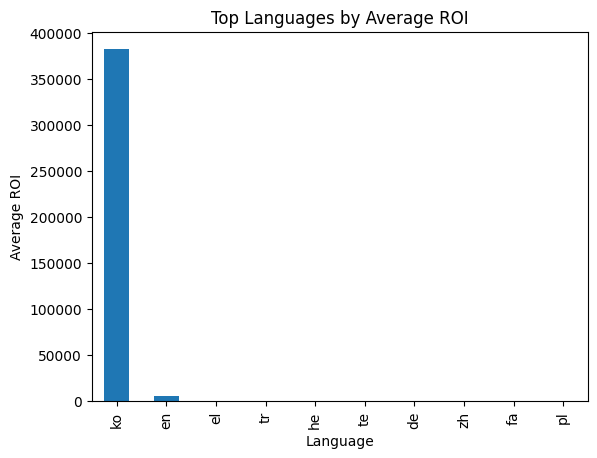

In [12]:
#Top Languages ROI Graph
import matplotlib.pyplot as plt

language_roi.head(10).plot(kind='bar')

plt.title("Top Languages by Average ROI")
plt.xlabel("Language")
plt.ylabel("Average ROI")
plt.show()

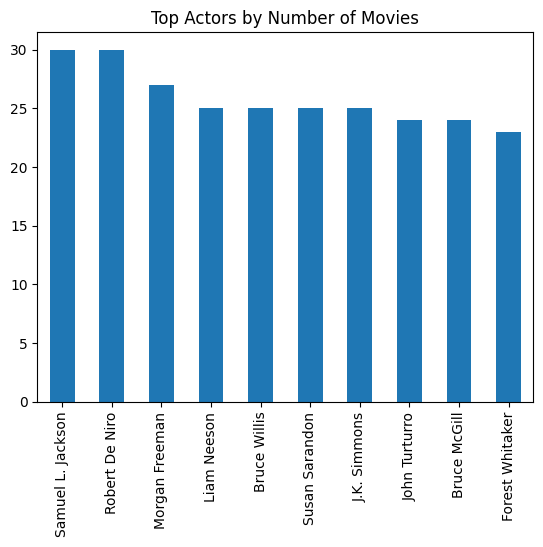

In [13]:
#Top Actors Frequency Graph
actor_series.value_counts().head(10).plot(kind='bar')

plt.title("Top Actors by Number of Movies")
plt.show()